In [80]:
# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "../../data/Leaf/RiceLeafsDisease"

TRAIN_DIR = os.path.join(DATA_ROOT, "train_aug")
VAL_DIR   = os.path.join(DATA_ROOT, "validation")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

OUT_DIR = "./outputs_vit_final"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Device & seed
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


In [81]:
NUM_CLASSES = 6
IMG_SIZE = 224
BATCH_SIZE = 12
EPOCHS = 10
NUM_WORKERS = 2
ACCUM_STEPS = 1

# Hyperparameter sweep (FINAL)
LR_LIST = [1e-4, 5e-5, 3e-5]
WEIGHT_DECAY_LIST = [1e-4, 5e-4]
LABEL_SMOOTHING_LIST = [0.0, 0.1]
DROPOUT_LIST = [0.0, 0.2]


In [82]:
def load_dataloaders():
    train_ds = datasets.ImageFolder(
        TRAIN_DIR, transform=get_transforms(IMG_SIZE, train=True)
    )
    val_ds = datasets.ImageFolder(
        VAL_DIR, transform=get_transforms(IMG_SIZE, train=False)
    )
    test_ds = datasets.ImageFolder(
        TEST_DIR, transform=get_transforms(IMG_SIZE, train=False)
    )

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS
    )

    print("Classes:", train_ds.classes)
    return train_loader, val_loader, test_loader, train_ds.classes


In [83]:
def get_transforms(img_size, train=True):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(0.2, 0.2, 0.15, 0.02),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            ),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(int(img_size * 1.14)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            ),
        ])


In [84]:
train_loader, val_loader, test_loader, class_names = load_dataloaders()


Classes: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [69]:
import os
from PIL import Image
import imagehash

def get_image_hashes(folder):
    hashes = {}
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                path = os.path.join(root, file)
                try:
                    img = Image.open(path).convert("RGB")
                    h = imagehash.phash(img)
                    hashes.setdefault(h, []).append(path)
                except Exception as e:
                    print(f"Error reading {path}: {e}")
    return hashes


TRAIN_DIR = "../../data/leaf/riceLeafsDisease/train"
TEST_DIR  = "../../data/leaf/riceLeafsDisease/test"

train_hashes = get_image_hashes(TRAIN_DIR)
test_hashes  = get_image_hashes(TEST_DIR)

# Find common hashes
common_hashes = set(train_hashes.keys()) & set(test_hashes.keys())

print(f"Matching images found: {len(common_hashes)}")

deleted = 0

for h in common_hashes:
    for test_img_path in test_hashes[h]:
        try:
            os.remove(test_img_path)
            print("DELETED TEST IMAGE:", test_img_path)
            deleted += 1
        except Exception as e:
            print(f"Failed to delete {test_img_path}: {e}")

print(f"\nTotal test images deleted: {deleted}")


Matching images found: 0

Total test images deleted: 0


### 85 test Images Per class

In [55]:
from timm import create_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = create_model(
    "vit_tiny_patch16_224",   # ← EXACT same model
    pretrained=False,
    num_classes=NUM_CLASSES  #  should always bes AME as training
)

model = model.to(device)

import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# load best model
checkpoint = torch.load("outputs_vit_final/vit_best.pt")
model.load_state_dict(checkpoint)
model.eval()


import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Test accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")




TEST Accuracy: 96.85%


Confusion Matrix:
 [[84  0  0  0  0  0]
 [ 0 78  2  5  0  0]
 [ 0  0 85  0  0  0]
 [ 0  3  2 80  0  0]
 [ 0  0  0  2 82  0]
 [ 0  1  0  1  0 83]]


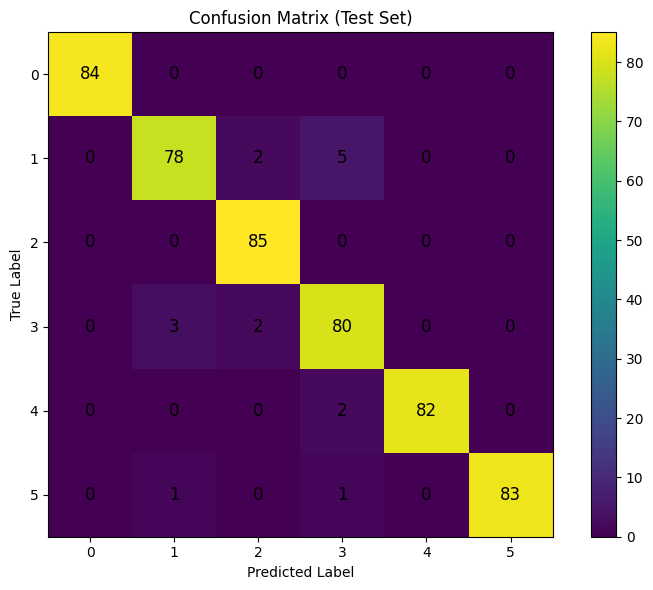

In [56]:
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12
        )

plt.tight_layout()
plt.show()


### Augmenting More with Brightness and all to check the model sensitivity to images variance 199 images per class

In [75]:
import os
import random
from PIL import Image, ImageEnhance

TARGET_COUNT = 200
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def augment_image(img):
    """Apply one random augmentation (no cropping)"""
    ops = []

    # Flips
    ops.append(lambda x: x.transpose(Image.FLIP_LEFT_RIGHT))
    ops.append(lambda x: x.transpose(Image.FLIP_TOP_BOTTOM))

    # Rotations
    ops.append(lambda x: x.rotate(90, expand=True))
    ops.append(lambda x: x.rotate(180, expand=True))
    ops.append(lambda x: x.rotate(270, expand=True))

    # Brightness
    ops.append(lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.7, 1.3)))

    # Contrast
    ops.append(lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.7, 1.3)))

    # Color (saturation)
    ops.append(lambda x: ImageEnhance.Color(x).enhance(random.uniform(0.7, 1.3)))

    # Sharpness
    ops.append(lambda x: ImageEnhance.Sharpness(x).enhance(random.uniform(0.8, 1.5)))

    op = random.choice(ops)
    return op(img)


def augment_test_folder(test_root):
    for class_name in os.listdir(test_root):
        class_path = os.path.join(test_root, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTS)]
        count = len(images)

        print(f"\nClass: {class_name} | Current: {count}")

        if count >= TARGET_COUNT:
            print("Already sufficient, skipping.")
            continue

        i = 0
        while count < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path).convert("RGB")
                aug_img = augment_image(img)

                new_name = f"aug_{i}_{img_name}"
                save_path = os.path.join(class_path, new_name)

                aug_img.save(save_path, quality=95)
                count += 1
                i += 1

                print(f"Added: {new_name} | Total: {count}")

            except Exception as e:
                print(f"Error augmenting {img_name}: {e}")

        print(f"✅ Final count for {class_name}: {count}")


# =========================
# RUN
# =========================
TEST_FOLDER = "../../data/leaf/riceLeafsDisease/test"
augment_test_folder(TEST_FOLDER)



Class: bacterial_leaf_blight | Current: 196
Added: aug_0_bacterial_val (51).JPG | Total: 197
Added: aug_1_aug_11_aug_0_bacterial_val (32).jpg | Total: 198
Added: aug_2_aug_34_bacterial_val (33).jpg | Total: 199
Added: aug_3_aug_21_aug_9_bacterial_val (86).JPG | Total: 200
✅ Final count for bacterial_leaf_blight: 200

Class: brown_spot | Current: 187
Added: aug_0_brown_val (74).jpg | Total: 188
Added: aug_1_aug_7_brown_val (14).jpg | Total: 189
Added: aug_2_aug_11_brown_val (29).jpg | Total: 190
Added: aug_3_aug_33_brown_val (17).JPG | Total: 191
Added: aug_4_brown_val (23).jpg | Total: 192
Added: aug_5_brown_val (43).jpg | Total: 193
Added: aug_6_brown_val (83).jpg | Total: 194
Added: aug_7_aug_9_brown_val (33).jpg | Total: 195
Added: aug_8_aug_0_brown_val (17).JPG | Total: 196
Added: aug_9_brown_val (79).jpg | Total: 197
Added: aug_10_aug_26_brown_val (62).jpg | Total: 198
Added: aug_11_aug_49_brown_val (77).jpg | Total: 199
Added: aug_12_aug_18_brown_val (29).jpg | Total: 200
✅ Fina

Accuracy measures the proportion of correctly classified images among all samples and is used to provide an overall summary of the model’s prediction performance.

In [85]:
from timm import create_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = create_model(
    "vit_tiny_patch16_224",   # ← EXACT same model
    pretrained=False,
    num_classes=NUM_CLASSES  #  should always bes AME as training
)

model = model.to(device)

import torch
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# load best model
checkpoint = torch.load("outputs_vit_final/vit_best.pt")
model.load_state_dict(checkpoint)
model.eval()


import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Test accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")




TEST Accuracy: 94.92%


Bacterial leaf blight achieved very high precision and recall (F1-score = 0.9848), indicating that the model reliably detects this disease with minimal misclassification.

Brown spot showed comparatively lower precision and recall (F1-score = 0.9158), suggesting moderate confusion with visually similar disease patterns.

Healthy leaves obtained perfect recall with high precision (F1-score = 0.9804), demonstrating that the model effectively avoids misclassifying diseased samples as healthy.

Leaf blast recorded the lowest precision among all classes (F1-score = 0.8884), indicating occasional false positives likely due to overlapping visual symptoms with other diseases.

Leaf scald achieved excellent performance (F1-score = 0.9717), confirming strong class separability.

Narrow brown spot maintained perfect precision with slightly reduced recall (F1-score = 0.9583), indicating conservative but accurate predictions.

In [94]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average=None
)

for cls, p, r, f, s in zip(class_names, precision, recall, f1, support):
    print(f"{cls:25s} | Precision: {p:.4f} | Recall: {r:.4f} | F1-score: {f:.4f} | Support: {s}")


bacterial_leaf_blight     | Precision: 1.0000 | Recall: 0.9700 | F1-score: 0.9848 | Support: 200
brown_spot                | Precision: 0.9069 | Recall: 0.9250 | F1-score: 0.9158 | Support: 200
healthy                   | Precision: 0.9615 | Recall: 1.0000 | F1-score: 0.9804 | Support: 200
leaf_blast                | Precision: 0.8462 | Recall: 0.9350 | F1-score: 0.8884 | Support: 200
leaf_scald                | Precision: 1.0000 | Recall: 0.9450 | F1-score: 0.9717 | Support: 200
narrow_brown_spot         | Precision: 1.0000 | Recall: 0.9200 | F1-score: 0.9583 | Support: 200


The confusion matrix presents a detailed breakdown of correct and incorrect predictions for each class and is used to analyze class-wise errors and misclassification patterns.

It shows that the model achieves near-perfect classification for the healthy class with no misclassifications, while most errors occur between visually similar disease categories such as leaf blast, brown spot, and narrow brown spot, indicating that remaining misclassifications are primarily due to overlapping symptom patterns rather than systematic model failure.

Confusion Matrix:
 [[194   0   0   6   0   0]
 [  0 185   4  11   0   0]
 [  0   0 200   0   0   0]
 [  0   9   4 187   0   0]
 [  0   0   0  11 189   0]
 [  0  10   0   6   0 184]]


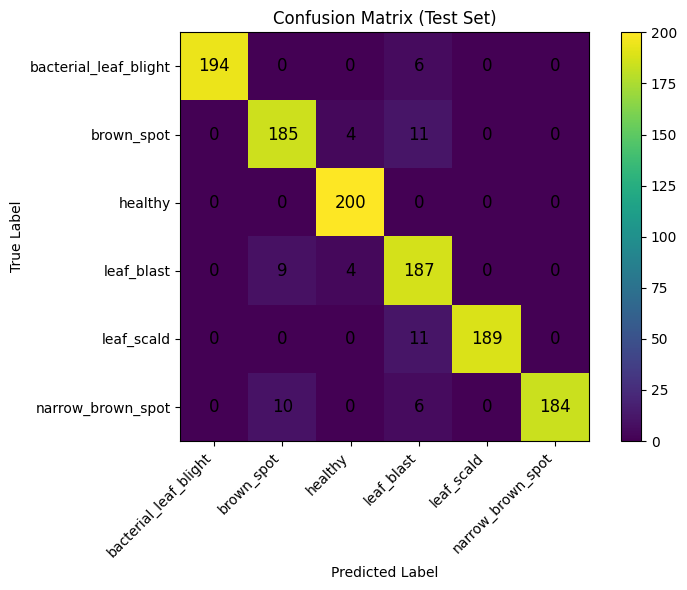

In [87]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "narrow_brown_spot"
]

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()


Per Class Accuracy

In [88]:
import numpy as np

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(class_names, per_class_acc):
    print(f"{cls}: {acc:.4f}")


bacterial_leaf_blight: 0.9700
brown_spot: 0.9250
healthy: 1.0000
leaf_blast: 0.9350
leaf_scald: 0.9450
narrow_brown_spot: 0.9200


The Macro F1-score measures the average F1-score across all classes by giving equal importance to each class, while the Weighted F1-score averages F1-scores by weighting them according to the number of samples per class, and their identical values here indicate that the dataset is perfectly balanced and the model performs consistently across all classes.

The identical values of Macro F1 (0.9499) and Weighted F1 (0.9499) indicate that all classes contribute equally to the model’s performance, confirming that the dataset is balanced and that the model achieves uniform classification quality across all disease categories without being biased toward any particular class.

In [89]:
from sklearn.metrics import precision_recall_fscore_support

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro"
)

p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted"
)

print("Macro F1:", f_macro)
print("Weighted F1:", f_weighted)


Macro F1: 0.949903676354626
Weighted F1: 0.9499036763546261


Cohen’s Kappa quantifies the agreement between predicted and true labels beyond chance and is used to confirm that the model’s performance is genuinely reliable rather than coincidental.

Score of 0.939 indicates an almost perfect agreement between the predicted and true labels after accounting for chance agreement, demonstrating that the model’s classification performance is highly reliable and substantially better than random guessing.

In [91]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(all_labels, all_preds)
print("Cohen’s Kappa:", kappa)


Cohen’s Kappa: 0.939


Matthews Correlation Coefficient measures the overall quality of classification by considering true and false positives and negatives simultaneously and is used to provide a reliable, balanced evaluation even when class distributions are imbalanced.

An MCC value of 0.9394 indicates a very strong positive correlation between the predicted and true labels, confirming that the model achieves highly balanced and reliable classification performance across all classes, even in the presence of potential class imbalance.

In [92]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(all_labels, all_preds)
print("MCC:", mcc)


MCC: 0.9393656409567581
